# <center style="font-family: consolas; font-size: 32px; font-weight: bold;">  Hands-On LangChain for LLMs App: Answering Questions From Documents </center>
***


In the previous notebooks of this series, we discussed how to load documents, split them, and then find documents related to a specific question. Now, let’s take the next step: using those documents and the original question to get an answer from a language model. 

This notebook will walk you through the process, explaining different ways to do question answering with the documents you’ve found. After sorting out storage and getting the right data, we’re now at the point where we use a language model to find the answers we need.

#### <a id="top"></a>
# <div style="box-shadow: rgb(60, 121, 245) 0px 0px 0px 3px inset, rgb(255, 255, 255) 10px -10px 0px -3px, rgb(31, 193, 27) 10px -10px, rgb(255, 255, 255) 20px -20px 0px -3px, rgb(255, 217, 19) 20px -20px, rgb(255, 255, 255) 30px -30px 0px -3px, rgb(255, 156, 85) 30px -30px, rgb(255, 255, 255) 40px -40px 0px -3px, rgb(255, 85, 85) 40px -40px; padding:20px; margin-right: 40px; font-size:30px; font-family: consolas; text-align:center; display:fill; border-radius:15px; color:rgb(60, 121, 245);"><b>Table of contents</b></div>

<div style="background-color: rgba(60, 121, 245, 0.03); padding:30px; font-size:15px; font-family: consolas;">
<ul>
    <li><a href="#1" target="_self" rel=" noreferrer nofollow">1. Overall Workflow for Retrieval Augmented Generation (RAG) </a></li> 
    <li><a href="#2" target="_self" rel=" noreferrer nofollow">2. Getting Started & Setting Environment Variables </a></li> 
    <li><a href="#3" target="_self" rel=" noreferrer nofollow">3. Prompt Development for RetrievalQA  </a></li> 
    <li><a href="#4" target="_self" rel=" noreferrer nofollow">4. RetrievalQA with Map Reduce & Refined Chain </a></li>
    <li><a href="#5" target="_self" rel=" noreferrer nofollow">5. RetrievalQA Limitations </a></li>    
</ul>
</div>

***

<a id="1"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34);"> <b> 1. Overall Workflow for Retrieval Augmented Generation (RAG) </b></div>


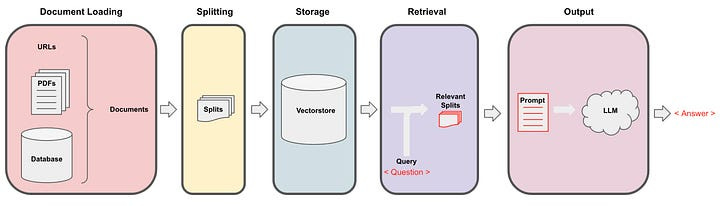

The general flow for this goes, the question comes in, we look up the relevant documents, we then pass those splits along with a system prompt and the human question to the language model and get the answer. By default, we just pass all the chunks into the same context window, into the same call of the language model. However, there are a few different methods we can use that have pros and cons to that. Most of the pros come from the fact that sometimes there can be a lot of documents and you just simply can’t pass them all into the same context window. MapReduce, Refine, and MapRerank are three methods to get around this issue of short context windows, and we’ll cover a few of them in this notebook


<a id="2"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34);"> <b> 2. Getting Started & Setting Environment Variables </b></div>


Let's start first with loading our environment variables and the important packages that we will be using in this notebook:



In [1]:
!pip install -r requirements.txt
!pip install -r requirements.txt
!pip install pypdf -q
!pip install yt_dlp -q
!pip install pydub -q
!pip install unstructured -q
!pip install docx2txt -q
!pip install openai -q
!pip install python-dotenv -q
!pip install xlrd -q
!pip install tiktoken -q
!pip install chromadb -q
!pip install lark -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-cv 0.9.0 requires keras-core, which is not installed.
keras-nlp 0.12.1 requires keras-core, which is not installed.
tensorflow-decision-forests 1.8.1 requires wurlitzer, which is not installed.
apache-beam 2.46.0 requires dill<0.3.2,>=0.3.1.1, but you have dill 0.3.8 which is incompatible.
apache-beam 2.46.0 requires numpy<1.25.0,>=1.14.3, but you have numpy 1.26.4 which is incompatible.
apache-beam 2.46.0 requires pyarrow<10.0.0,>=3.0.0, but you have pyarrow 16.1.0 which is incompatible.
google-cloud-bigquery 2.34.4 requires packaging<22.0dev,>=14.3, but you have packaging 24.2 which is incompatible.
jupyterlab 4.2.1 requires jupyter-lsp>=2.0.0, but you have jupyter-lsp 1.5.1 which is incompatible.
jupyterlab-lsp 5.1.0 requires jupyter-lsp>=2.0.0, but you have jupyter-lsp 1.5.1 which is incompatible.
kfp 2.

In [2]:
from openai import OpenAI
import openai
import os
import numpy as np
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
openai.api_key = user_secrets.get_secret("openai_api")
client = OpenAI(
    # This is the default and can be omitted
    api_key=openai.api_key,
)

llm_model = "GPT-4o"

We will then load in our vector database the machine learning lectures we have been using in the previous notebooks. 

In [3]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma

embedding = OpenAIEmbeddings(openai_api_key=openai.api_key)

# Load PDF
loaders = [
    # Duplicate documents on purpose - messy data
    PyPDFLoader("/kaggle/input/machine-learning-lectures/MachineLearning-Lecture01.pdf"),
    PyPDFLoader("/kaggle/input/machine-learning-lectures/MachineLearning-Lecture01.pdf"),
    PyPDFLoader("/kaggle/input/machine-learning-lectures/MachineLearning-Lecture02.pdf"),
    PyPDFLoader("/kaggle/input/machine-learning-lectures/MachineLearning-Lecture03.pdf")
]
docs = []
for loader in loaders:
    docs.extend(loader.load())


text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 150
)

splits = text_splitter.split_documents(docs)
len(splits)
    
persist_directory = 'docs/chroma/'
!rm -rf ./docs/chroma  # remove old database files if any

vectordb = Chroma.from_documents(
    documents=splits,
    embedding=embedding,
    persist_directory=persist_directory
)

print(vectordb._collection.count())

/tmp/ipykernel_18/983296141.py:6: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embedding = OpenAIEmbeddings(openai_api_key=openai.api_key)


209


We can see that it has the same 209 documents from before. Let's also do a quick check of similarity search to make sure it’s working. We will ask the following question: what are the major topics for this class?



In [4]:
question = "What are major topics for this class?"
docs = vectordb.similarity_search(question,k=3)
len(docs)

3

Now, we initialize the language model that we’re going to use to answer the question. We’re going to use the chat open AI model, GPT 3.5, and we’re going to set the temperature equal to zero. This is a good option when we want factual answers to come out because it’s going to have low variability and usually just give us the highest fidelity, most reliable answers.



In [5]:
from langchain_openai import ChatOpenAI

# Fetch OpenAI API key securely
user_secrets = UserSecretsClient()
OPENAI_API_KEY = user_secrets.get_secret("openai_api")

llm_model = "gpt-4" 

# Initialize the LLM
llm = ChatOpenAI(model_name=llm_model, temperature=0, openai_api_key=OPENAI_API_KEY)

/tmp/ipykernel_18/12768340.py:10: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model_name=llm_model, temperature=0, openai_api_key=OPENAI_API_KEY)


Finally, we are then going to import the retrieval QA chain. This is doing question-answering backed by a retrieval step. We can create it by passing in a language model, and then the vector database as a retriever. We can then call it with the query being equal to the question that we want to ask. And then when we look at the result, we get an answer.


In [6]:
from langchain.chains import RetrievalQA

# Create the QA chain with the retriever
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=vectordb.as_retriever()  # Ensure vectordb is properly set up
)

# Query the chain
result = qa_chain({"query": question})
print(result["result"])


/tmp/ipykernel_18/3777959211.py:10: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = qa_chain({"query": question})


The major topics for this class include statistics, algebra, and machine learning.


We can see from the answer that the major topic for this class is machine learning. Additionally, the class may cover statistics and algebra as refreshers in the discussion sections.

<a id="3"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34);"> <b> 3. Prompt Development for RetrievalQA </b></div>


Let’s try to understand a little bit better what’s going on underneath the hood and expose a few of the different knobs that you can turn. One of the main important parts here is the prompt that we’re using.

This is the prompt that takes in the documents and the question and passes it to a language model. Let's start with defining a prompt template. It has some instructions about how to use the following pieces of context, and then it has a placeholder for a context variable. This is where the documents will go, and a placeholder for the questions variable. 


 

In [7]:
from langchain_core.prompts import PromptTemplate

# Build prompt
template = """Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer. Use three sentences maximum. Keep the answer as concise as possible. Always say "thanks for asking!" at the end of the answer. 
{context}
Question: {question}
Helpful Answer:"""
QA_CHAIN_PROMPT = PromptTemplate.from_template(template)

We can now create a new retrieval QA chain. We’re going to use the same language model as before and the same vector databases as before, but we’re going to pass in a few new arguments. We’ve got the return source document argument set to true. This will let us easily inspect the documents that we retrieve. Then we’re also going to pass in a prompt equal to the QA chain prompt that we defined above. 



In [8]:
# Run chain
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever(),
    return_source_documents=True,
    chain_type_kwargs={"prompt": QA_CHAIN_PROMPT}
)


Let’s try out a new question “Is probability a class topic?” and then we will print the answer we got. 

In [9]:
question = "Is probability a class topic?"
result = qa_chain({"query": question})
result["result"]


"Yes, basic probability and statistics are assumed knowledge for this class. However, if it's been a while since you've studied these topics, they will be reviewed in the discussion sections. Thanks for asking!"

We can see that probability is covered in the class. It was very nice when it responded to us as well. For a little bit better intuition as to where it’s getting this data from, we can take a look at some of the source documents that were returned. If you look through them, you should see that all the information that was answered is in one of these source documents.



In [10]:
result["source_documents"][0]

Document(metadata={'page': 4, 'page_label': '5', 'source': '/kaggle/input/machine-learning-lectures/MachineLearning-Lecture01.pdf'}, page_content="of this class will not be very program ming intensive, although we will do some \nprogramming, mostly in either MATLAB or Octa ve. I'll say a bit more about that later.  \nI also assume familiarity with basic proba bility and statistics. So most undergraduate \nstatistics class, like Stat 116 taught here at Stanford, will be more than enough. I'm gonna \nassume all of you know what ra ndom variables are, that all of you know what expectation \nis, what a variance or a random variable is. And in case of some of you, it's been a while \nsince you've seen some of this material. At some of the discussion sections, we'll actually \ngo over some of the prerequisites, sort of as  a refresher course under prerequisite class. \nI'll say a bit more about that later as well.  \nLastly, I also assume familiarity with basi c linear algebra. And again, mo

<a id="4"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34);"> <b> 4. RetrievalQA with Map Reduce & Refined Chain </b></div>


So far, we’ve been using the default technique which simply stuffs all the documents into the final prompt. This is good because it only involves one call to the language model. 

However, this does have the limitation that if there are too many documents, they may not all be able to fit inside the context window. A different type of technique that we can use to do question answering over documents is the map-reduce technique.

In this technique, each of the individual documents is first sent to the language model by itself to get an original answer. And then those answers are composed into a final answer with a final call to the language model. This involves many more calls to the language model, but it does have the advantage that it can operate over arbitrarily many documents. We can define it using the code below:



In [11]:
question = "Is probability a class topic?"

qa_chain_mr = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever(),
    chain_type="map_reduce",
)


Let's run to the previous question and use the map reduce chain:


In [12]:
result = qa_chain_mr({"query": question})
result["result"]


'The text does not provide information on probability being a class topic.'

There are two limitations to this method. First, it’s a lot slower because it how it works as it has to do multiple calls to the LLM. Second, the result is worse. There is no clear answer to this question based on the given portion of the document. This may occur because it’s answering based on each document individually. And so, if there is information that’s spread across two documents, it doesn’t have it all in the same context. 

We can overcome this by using the refined chain as it allows you to combine information, albeit sequentially, and it encourages more carrying over of information than the MapReduce chain.



In [13]:
qa_chain_mr = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever(),
    chain_type="refine"
)
result = qa_chain_mr({"query": question})
result["result"]


'Yes, probability is indeed a topic covered in this class. It is fundamental to understanding and interpreting linear regression and deriving learning algorithms. We will also be introducing a classification algorithm, which is particularly useful in scenarios with binary outcomes, such as medical diagnoses or predicting housing sales. For those who may need a refresher on related topics like statistics or algebra, we will cover these in the discussion sections. As the quarter progresses, we will also use these discussion sections to delve into extensions of the main lecture material, given the vastness of the field of machine learning.'

<a id="5"></a>
# <div style="box-shadow: rgba(0, 0, 0, 0.16) 0px 1px 4px inset, rgb(51, 51, 51) 0px 0px 0px 3px inset; padding:20px; font-size:32px; font-family: consolas; text-align:center; display:fill; border-radius:15px;  color:rgb(34, 34, 34);"> <b> 5. RetrievalQA Limitations </b></div>


One of the great things about chatbots and why they’re becoming so popular is that you can ask follow-up questions. You can ask for clarification about previous answers. So, let’s do that here. Let’s create a QA chain with default settings. 


In [14]:
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever()
)


We will ask it the previous question about probability and then let’s ask it a follow-up question. 



In [15]:
question = "Is probability a class topic?"
result = qa_chain({"query": question})
result["result"]

'Yes, basic probability and statistics are assumed knowledge for this class. The instructor assumes that all students know what random variables are, what expectation is, and what the variance of a random variable is. If some students need a refresher on these topics, they will be covered in the discussion sections.'

It mentions that probability should be a prerequisite, so let’s ask, why are those prerequisites needed? 



In [16]:
question = "why are those prerequesites needed?"
result = qa_chain({"query": question})
result["result"]


'The prerequisites are needed because the class involves understanding and applying complex machine learning algorithms. Basic knowledge of computer science is required to understand the programming and algorithmic aspects of the course. Familiarity with big O notation is important for understanding the time and space complexity of these algorithms. \n\nThe course also involves some programming, mostly in MATLAB or Octave, hence the need for basic computer skills. \n\nUnderstanding of basic probability and statistics is crucial because many machine learning algorithms are based on statistical concepts such as random variables, expectation, and variance. \n\nLastly, familiarity with basic linear algebra is needed because operations on matrices and vectors are fundamental in many machine learning algorithms. Knowing how to multiply matrices and vectors, understanding matrix inverses, and knowing what an eigenvector of a matrix is, are all important for understanding and implementing thes

The prerequisites for the class are assumed to be basic knowledge of computer science and basic computer skills and principles. That doesn’t relate at all to the answer before where we were asking about probability. The chain that we’re using doesn’t have any concept of state. It doesn’t remember what previous questions or previous answers were. For that, we’ll need to introduce memory, and that’s what we’ll cover in the next notebook.

# <div style="box-shadow: rgba(240, 46, 170, 0.4) -5px 5px inset, rgba(240, 46, 170, 0.3) -10px 10px inset, rgba(240, 46, 170, 0.2) -15px 15px inset, rgba(240, 46, 170, 0.1) -20px 20px inset, rgba(240, 46, 170, 0.05) -25px 25px inset; padding:20px; font-size:30px; font-family: consolas; display:fill; border-radius:15px; color: rgba(240, 46, 170, 0.7)"> <b> ༼⁠ ⁠つ⁠ ⁠◕⁠‿⁠◕⁠ ⁠༽⁠つ Thank You!</b></div>

<p style="font-family:verdana; color:rgb(34, 34, 34); font-family: consolas; font-size: 16px;"> 💌 Thank you for taking the time to read through my notebook. I hope you found it interesting and informative. If you have any feedback or suggestions for improvement, please don't hesitate to let me know in the comments. <br><br> 🚀 If you liked this notebook, please consider upvoting it so that others can discover it too. Your support means a lot to me, and it helps to motivate me to create more content in the future. <br><br> ❤️ Once again, thank you for your support, and I hope to see you again soon!</p>